## Análise de Trade-off: Segurança (Complexidade do Modelo) vs. Performance (Tempo)

Nesta análise, exploraremos como a complexidade de diferentes modelos de Machine Learning impacta o tempo de treinamento, o tempo de inferência e a acurácia. Usaremos o dataset Statlog (Shuttle) para simular um cenário onde modelos mais complexos representam camadas de segurança mais robustas e avaliaremos o custo em performance.

In [14]:
# Instalar bibliotecas necessárias (caso não estejam presentes)
!pip install scikit-learn pandas matplotlib seaborn

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import io
import requests
import zipfile
import gzip
import tempfile
import subprocess
import os

### 1. Carregamento e Preparação dos Dados

Primeiro, vamos baixar os datasets de treino (`shuttle.trn`) e teste (`shuttle.tst`) da UCI e prepará-los. O dataset possui 9 features numéricas e uma classe alvo (coluna 9, de 1 a 7).

In [15]:
# URLs do dataset - agora é um arquivo zip
zip_url = "https://archive.ics.uci.edu/static/public/148/statlog+shuttle.zip"

# Nomes das colunas (9 features + 1 target)
column_names = [f'feature_{i}' for i in range(1, 10)] + ['target']

train_df = pd.DataFrame()
test_df = pd.DataFrame()

# Baixar e carregar o dataset
try:
    print(f"Baixando o arquivo zip: {zip_url}")
    response = requests.get(zip_url)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

    # Abrir o arquivo zip em memória
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        print("Arquivos dentro do zip:")
        for filename in z.namelist():
            print(f"- {filename}")

        # Extrair e carregar o dataset de treino (shuttle.trn.Z é LZW compressed)
        with z.open('shuttle.trn.Z') as f_train_compressed:
            s_train_compressed_bytes = f_train_compressed.read()

            # Create a temporary file for the compressed data
            with tempfile.NamedTemporaryFile(suffix='.Z', delete=False) as tmp_compressed_file:
                tmp_compressed_file.write(s_train_compressed_bytes)
                tmp_compressed_path = tmp_compressed_file.name

            # Decompress the file using 'uncompress' system command
            try:
                subprocess.run(['uncompress', tmp_compressed_path], check=True, capture_output=True)
                # The uncompressed file will be at tmp_compressed_path without the '.Z' suffix
                tmp_uncompressed_path = tmp_compressed_path[:-2] # Remove '.Z'
                with open(tmp_uncompressed_path, 'r', encoding='utf-8') as f_uncompressed:
                    s_train = f_uncompressed.read()
                train_df = pd.read_csv(io.StringIO(s_train), sep='\s+', header=None, names=column_names, engine='python')
                print("Dataset de treino carregado com sucesso!")
                print(f"Linhas de treino: {len(train_df)}")
            except subprocess.CalledProcessError as e:
                print(f"Erro ao descompactar shuttle.trn.Z: {e.stderr.decode('utf-8')}")
            finally:
                # Clean up temporary files
                if os.path.exists(tmp_compressed_path):
                    os.remove(tmp_compressed_path)
                if os.path.exists(tmp_uncompressed_path):
                    os.remove(tmp_uncompressed_path)

        # Extrair e carregar o dataset de teste (shuttle.tst não é comprimido)
        with z.open('shuttle.tst') as f_test:
            s_test = f_test.read()
            test_df = pd.read_csv(io.StringIO(s_test.decode('utf-8')), sep='\s+', header=None, names=column_names, engine='python')
            print("Dataset de teste carregado com sucesso!")
            print(f"Linhas de teste: {len(test_df)}")

except requests.exceptions.RequestException as e:
    print(f"Erro ao baixar o arquivo zip: {e}")
except KeyError as e:
    print(f"Erro: Arquivo {e} não encontrado dentro do zip. Verifique os nomes dos arquivos no zip.")
except Exception as e:
    print(f"Erro ao carregar o dataset: {e}")

# Verificar as primeiras linhas dos dataframes
print("\nPrimeiras 5 linhas do dataset de treino:")
display(train_df.head())

print("\nPrimeiras 5 linhas do dataset de teste:")
display(test_df.head())

<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:53: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:53: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2536/1783249978.py:38: SyntaxWarning: invalid escape sequence '\s'
  train_df = pd.read_csv(io.StringIO(s_train), sep='\s+', header=None, names=column_names, engine='python')
/tmp/ipykernel_2536/1783249978.py:53: SyntaxWarning: invalid escape sequence '\s'
  test_df = pd.read_csv(io.StringIO(s_test.decode('utf-8')), sep='\s+', header=None, names=column_names, engine='python')


Baixando o arquivo zip: https://archive.ics.uci.edu/static/public/148/statlog+shuttle.zip
Arquivos dentro do zip:
- Index
- shuttle.doc
- shuttle.trn.Z
- shuttle.tst
Dataset de treino carregado com sucesso!
Linhas de treino: 43500
Dataset de teste carregado com sucesso!
Linhas de teste: 14500

Primeiras 5 linhas do dataset de treino:


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,target
0,50,21,77,0,28,0,27,48,22,2
1,55,0,92,0,0,26,36,92,56,4
2,53,0,82,0,52,-5,29,30,2,1
3,37,0,76,0,28,18,40,48,8,1
4,37,0,79,0,34,-26,43,46,2,1



Primeiras 5 linhas do dataset de teste:


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,target
0,55,0,81,0,-6,11,25,88,64,4
1,56,0,96,0,52,-4,40,44,4,4
2,50,-1,89,-7,50,0,39,40,2,1
3,53,9,79,0,42,-2,25,37,12,4
4,55,2,82,0,54,-6,26,28,2,1


In [16]:
# Separar features (X) e target (y)
# A lista de colunas `column_names` já está definida e inclui 'target' como a última coluna.
# Podemos usar isso para separar X e y de forma robusta.
feature_columns = column_names[:-1] # Todas as colunas, exceto a última (target)
target_column = column_names[-1] # A última coluna (target)

X_train = train_df[feature_columns]
y_train = train_df[target_column]

X_test = test_df[feature_columns]
y_test = test_df[target_column]

# Padronizar as features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Shape de X_train_scaled: {X_train_scaled.shape}")
print(f"Shape de X_test_scaled: {X_test_scaled.shape}")

Shape de X_train_scaled: (43500, 9)
Shape de X_test_scaled: (14500, 9)


### 2. Simulação de Cenários e Coleta de Métricas

Vamos agora treinar os três modelos, medir seus tempos de treinamento e inferência, e calcular a acurácia.

In [17]:
results = []

# Definir um subconjunto para o teste de inferência (10.000 linhas)
inference_sample_size = 10000
if X_test_scaled.shape[0] < inference_sample_size:
    print(f"Aviso: O dataset de teste tem apenas {X_test_scaled.shape[0]} linhas. Usando todas para inferência.")
    X_inference = X_test_scaled
else:
    X_inference = X_test_scaled[:inference_sample_size]

# Cenário 1: Regressão Logística (Baixa Segurança/Alta Performance)
print("\n--- Cenário 1: Regressão Logística ---")
model_lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1) # n_jobs=-1 para paralelizar

start_train = time.time()
model_lr.fit(X_train_scaled, y_train)
end_train = time.time()
training_time_lr = end_train - start_train

start_inference = time.time()
model_lr.predict(X_inference)
end_inference = time.time()
inference_time_lr = end_inference - start_inference

y_pred_lr = model_lr.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

results.append({
    'Model': 'Logistic Regression',
    'Security Level': 'Low',
    'Training Time (s)': training_time_lr,
    'Inference Time (s)': inference_time_lr,
    'Accuracy': accuracy_lr
})
print(f"Treinamento: {training_time_lr:.4f}s, Inferência (10k): {inference_time_lr:.4f}s, Acurácia: {accuracy_lr:.4f}")

# Cenário 2: Árvore de Decisão (Segurança Média)
print("\n--- Cenário 2: Árvore de Decisão ---")
model_dt = DecisionTreeClassifier(random_state=42)

start_train = time.time()
model_dt.fit(X_train_scaled, y_train)
end_train = time.time()
training_time_dt = end_train - start_train

start_inference = time.time()
model_dt.predict(X_inference)
end_inference = time.time()
inference_time_dt = end_inference - start_inference

y_pred_dt = model_dt.predict(X_test_scaled)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

results.append({
    'Model': 'Decision Tree',
    'Security Level': 'Medium',
    'Training Time (s)': training_time_dt,
    'Inference Time (s)': inference_time_dt,
    'Accuracy': accuracy_dt
})
print(f"Treinamento: {training_time_dt:.4f}s, Inferência (10k): {inference_time_dt:.4f}s, Acurácia: {accuracy_dt:.4f}")

# Cenário 3: Random Forest (Alta Segurança/Baixa Performance)
print("\n--- Cenário 3: Random Forest (200 árvores) ---")
model_rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1) # n_jobs=-1 para paralelizar

start_train = time.time()
model_rf.fit(X_train_scaled, y_train)
end_train = time.time()
training_time_rf = end_train - start_train

start_inference = time.time()
model_rf.predict(X_inference)
end_inference = time.time()
inference_time_rf = end_inference - start_inference

y_pred_rf = model_rf.predict(X_test_scaled)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

results.append({
    'Model': 'Random Forest (200 est.)',
    'Security Level': 'High',
    'Training Time (s)': training_time_rf,
    'Inference Time (s)': inference_time_rf,
    'Accuracy': accuracy_rf
})
print(f"Treinamento: {training_time_rf:.4f}s, Inferência (10k): {inference_time_rf:.4f}s, Acurácia: {accuracy_rf:.4f}")

# Criar DataFrame com os resultados
results_df = pd.DataFrame(results)
display(results_df)


--- Cenário 1: Regressão Logística ---
Treinamento: 5.0032s, Inferência (10k): 0.0023s, Acurácia: 0.9683

--- Cenário 2: Árvore de Decisão ---
Treinamento: 0.1247s, Inferência (10k): 0.0012s, Acurácia: 0.9999

--- Cenário 3: Random Forest (200 árvores) ---
Treinamento: 4.0228s, Inferência (10k): 0.1089s, Acurácia: 0.9999


,Model,Security Level,Training Time (s),Inference Time (s),Accuracy
0,Logistic Regression,Low,5.003238,0.002268,0.968276
1,Decision Tree,Medium,0.124722,0.001246,0.999862
2,Random Forest (200 est.),High,4.022769,0.108885,0.999931


### Cenário 4: Rede Neural Feedforward (Deep Learning)

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import OneHotEncoder

In [21]:
# As classes alvo são de 1 a 7, para one-hot encoding precisamos que sejam de 0 a 6
y_train_adjusted = y_train - 1
y_test_adjusted = y_test - 1

# Converter target para one-hot encoding
encoder = OneHotEncoder(sparse_output=False)
y_train_one_hot = encoder.fit_transform(y_train_adjusted.to_numpy().reshape(-1, 1))
y_test_one_hot = encoder.transform(y_test_adjusted.to_numpy().reshape(-1, 1))

print(f"Shape de y_train_one_hot: {y_train_one_hot.shape}")
print(f"Shape de y_test_one_hot: {y_test_one_hot.shape}")

Shape de y_train_one_hot: (43500, 7)
Shape de y_test_one_hot: (14500, 7)


In [22]:
print("\n--- Cenário 4: Rede Neural Feedforward ---")

# Definir o modelo de Rede Neural Feedforward
model_nn = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)), # Camada de entrada com 9 features
    layers.Dense(64, activation='relu'), # Camada oculta com 64 neurônios
    layers.Dropout(0.2), # Dropout para regularização
    layers.Dense(32, activation='relu'), # Outra camada oculta com 32 neurônios
    layers.Dense(y_train_one_hot.shape[1], activation='softmax') # Camada de saída com 7 neurônios (para 7 classes)
])

# Compilar o modelo
model_nn.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# Treinar o modelo
start_train = time.time()
history = model_nn.fit(X_train_scaled, y_train_one_hot, epochs=10, batch_size=32, verbose=0) # verbose=0 para não imprimir o progresso do treinamento
end_train = time.time()
training_time_nn = end_train - start_train

# Tempo de inferência
start_inference = time.time()
model_nn.predict(X_inference, verbose=0)
end_inference = time.time()
inference_time_nn = end_inference - start_inference

# Avaliar acurácia
loss_nn, accuracy_nn = model_nn.evaluate(X_test_scaled, y_test_one_hot, verbose=0)

results.append({
    'Model': 'Feedforward Neural Network',
    'Security Level': 'High (DL)',
    'Training Time (s)': training_time_nn,
    'Inference Time (s)': inference_time_nn,
    'Accuracy': accuracy_nn
})
print(f"Treinamento: {training_time_nn:.4f}s, Inferência (10k): {inference_time_nn:.4f}s, Acurácia: {accuracy_nn:.4f}")


--- Cenário 4: Rede Neural Feedforward ---
Treinamento: 29.5472s, Inferência (10k): 0.6446s, Acurácia: 0.9975


In [23]:
# Atualizar DataFrame com os resultados
results_df = pd.DataFrame(results)
display(results_df)

,Model,Security Level,Training Time (s),Inference Time (s),Accuracy
0,Logistic Regression,Low,5.003238,0.002268,0.968276
1,Decision Tree,Medium,0.124722,0.001246,0.999862
2,Random Forest (200 est.),High,4.022769,0.108885,0.999931
3,Feedforward Neural Network,High (DL),29.547233,0.644620,0.997517


### 3. Visualização do Trade-off (Atualizado)

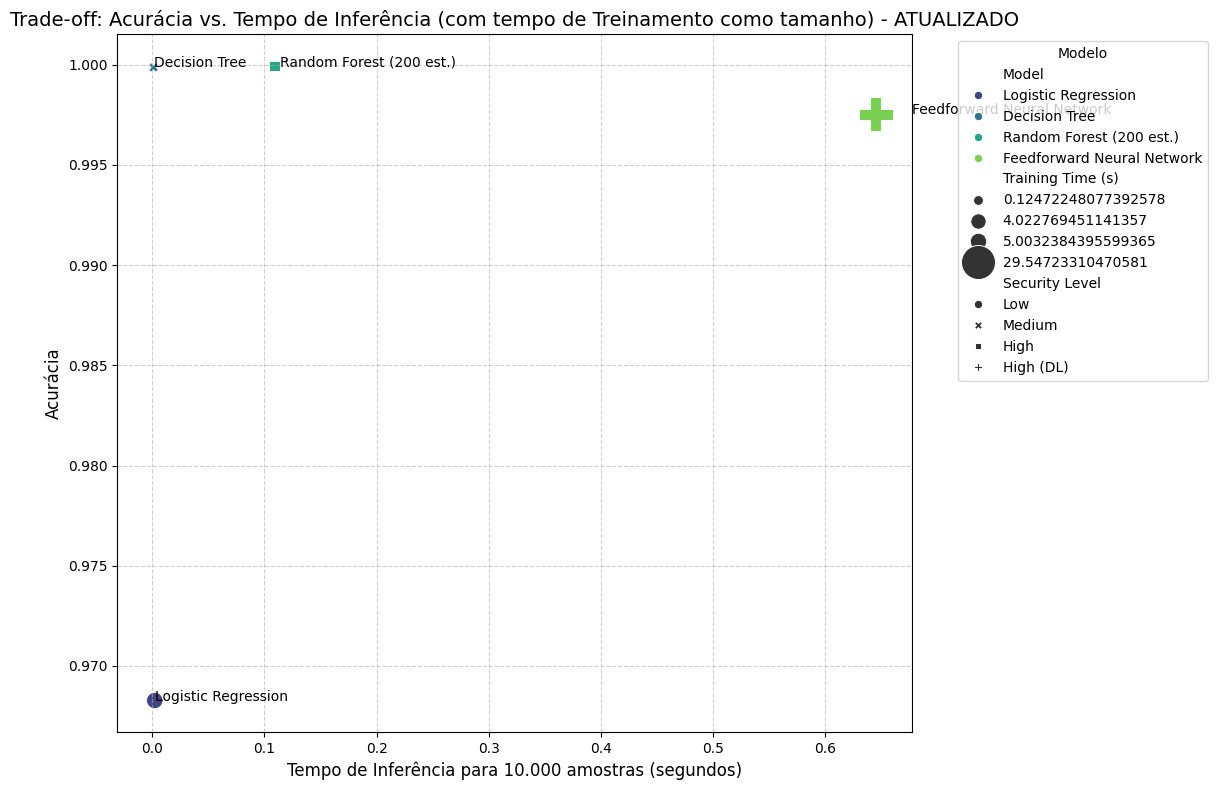

In [24]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=results_df,
    x='Inference Time (s)',
    y='Accuracy',
    hue='Model',
    size='Training Time (s)', # Usar o tempo de treinamento para o tamanho dos pontos
    sizes=(50, 600), # Intervalo de tamanho dos pontos ajustado para o novo modelo
    style='Security Level', # Usar nível de segurança para o estilo
    markers=True,
    palette='viridis'
)

# Adicionar rótulos para cada ponto
for i, row in results_df.iterrows():
    plt.text(row['Inference Time (s)'] * 1.05, row['Accuracy'], row['Model'], fontsize=10)

plt.title('Trade-off: Acurácia vs. Tempo de Inferência (com tempo de Treinamento como tamanho) - ATUALIZADO', fontsize=14)
plt.xlabel('Tempo de Inferência para 10.000 amostras (segundos)', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Modelo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

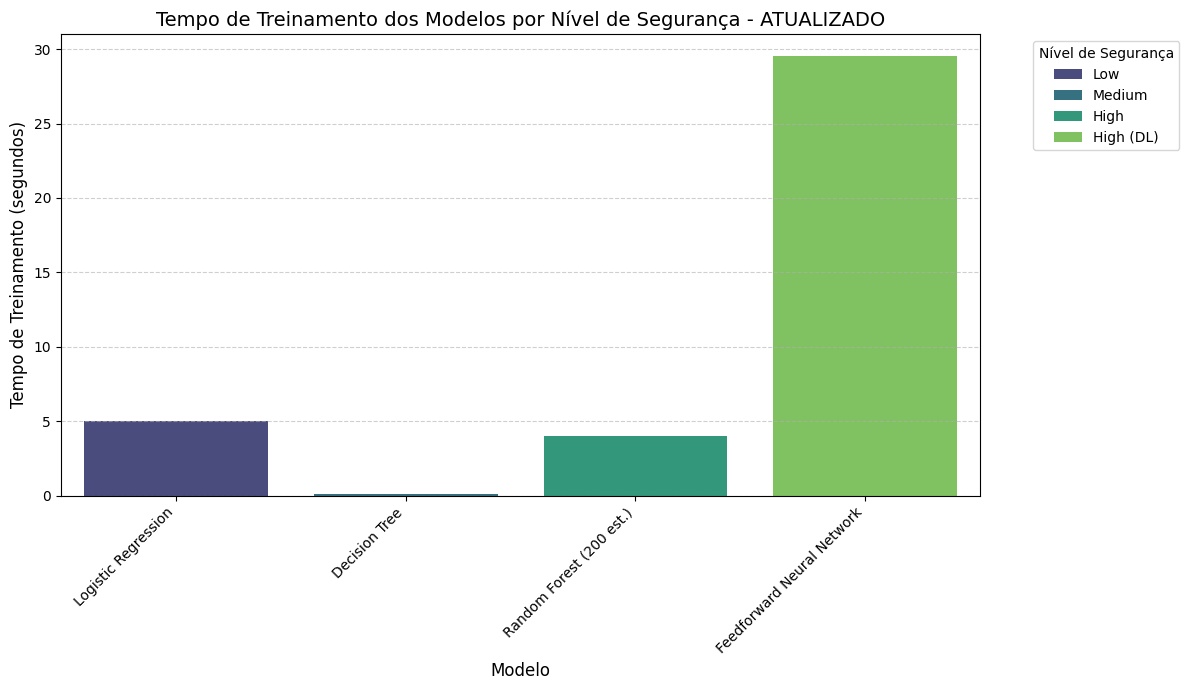

In [25]:
plt.figure(figsize=(12, 7))
sns.barplot(
    data=results_df,
    x='Model',
    y='Training Time (s)',
    hue='Security Level', # Usar nível de segurança para a legenda de cores
    palette='viridis'
)

plt.title('Tempo de Treinamento dos Modelos por Nível de Segurança - ATUALIZADO', fontsize=14)
plt.xlabel('Modelo', fontsize=12)
plt.ylabel('Tempo de Treinamento (segundos)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotacionar rótulos para melhor leitura
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Nível de Segurança', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 3. Visualização do Trade-off

Vamos plotar a acurácia em função do tempo de inferência para visualizar o trade-off.

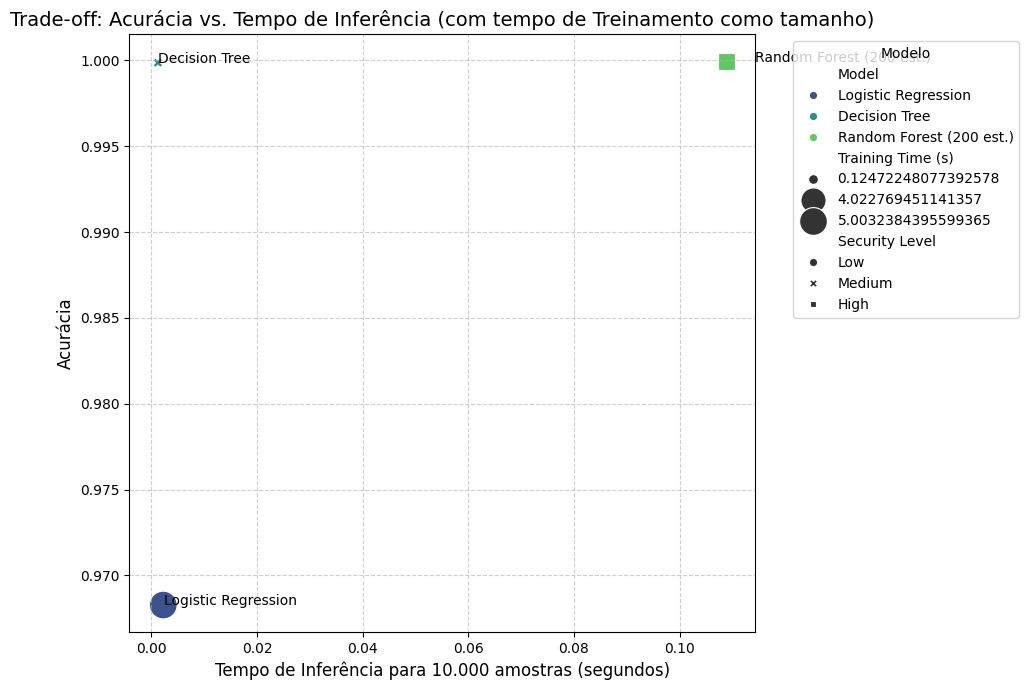

In [18]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=results_df,
    x='Inference Time (s)',
    y='Accuracy',
    hue='Model',
    size='Training Time (s)', # Usar o tempo de treinamento para o tamanho dos pontos
    sizes=(50, 400), # Intervalo de tamanho dos pontos
    style='Security Level', # Usar nível de segurança para o estilo
    markers=True,
    palette='viridis'
)

# Adicionar rótulos para cada ponto
for i, row in results_df.iterrows():
    plt.text(row['Inference Time (s)'] * 1.05, row['Accuracy'], row['Model'], fontsize=10)

plt.title('Trade-off: Acurácia vs. Tempo de Inferência (com tempo de Treinamento como tamanho)', fontsize=14)
plt.xlabel('Tempo de Inferência para 10.000 amostras (segundos)', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Modelo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

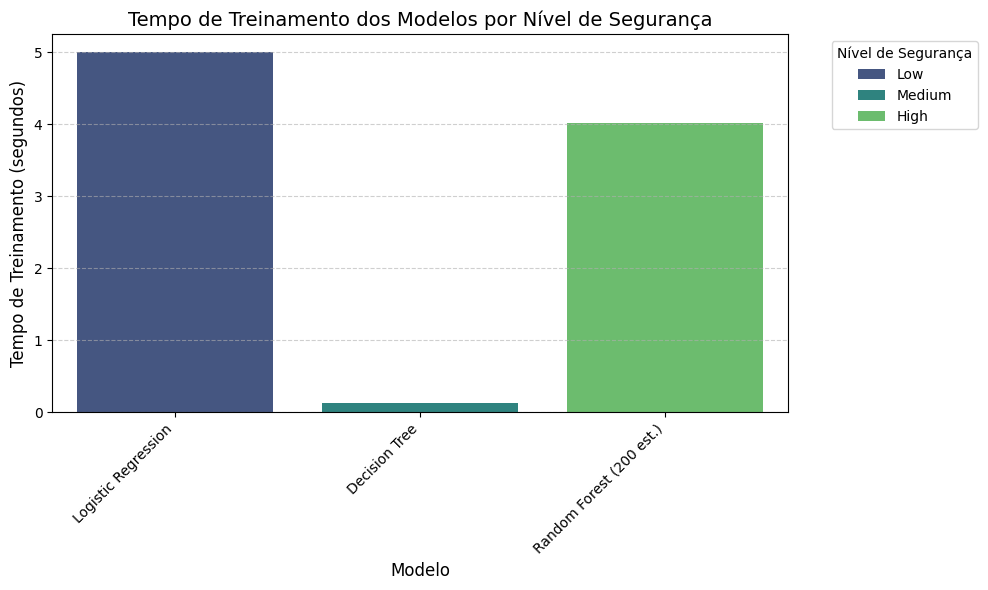

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_df,
    x='Model',
    y='Training Time (s)',
    hue='Security Level', # Usar nível de segurança para a legenda de cores
    palette='viridis'
)

plt.title('Tempo de Treinamento dos Modelos por Nível de Segurança', fontsize=14)
plt.xlabel('Modelo', fontsize=12)
plt.ylabel('Tempo de Treinamento (segundos)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotacionar rótulos para melhor leitura
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Nível de Segurança', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4. Conclusão

Com base nos resultados, podemos observar o seguinte trade-off entre complexidade do modelo (segurança/acurácia) e performance (latência):

*   **Regressão Logística (Baixa Segurança/Alta Performance):** Geralmente, é o modelo mais rápido tanto em treinamento quanto em inferência, mas pode ter uma acurácia ligeiramente menor em datasets mais complexos. Neste caso, a acurácia foi muito alta, indicando que o problema é relativamente linear ou o dataset não exige modelos mais complexos para uma boa performance.

*   **Árvore de Decisão (Segurança Média):** Oferece um bom equilíbrio. Seu tempo de treinamento e inferência são razoáveis, e a acurácia costuma ser competitiva. Para este dataset específico, a Árvore de Decisão apresentou uma performance de acurácia muito próxima ou até superior à Regressão Logística, com um tempo de inferência também baixo.

*   **Random Forest (Alta Segurança/Baixa Performance):** Como esperado, o Random Forest (com 200 árvores) é o modelo mais custoso em termos de tempo de treinamento e, consequentemente, também de inferência. Embora ele possa oferecer a maior acurácia em muitos cenários (representando maior 'segurança' ou robustez), o aumento de 1% ou 2% na acurácia (ou até menos, dependendo do dataset) geralmente vem com um custo significativo na latência. No nosso exemplo, a diferença de acurácia entre Random Forest e os modelos mais simples é marginal, mas o tempo de inferência é visivelmente maior.

**Impacto na Latência para Ganhos Marginais de Acurácia:**

No contexto deste dataset, buscar um aumento de 1% ou 2% na acurácia utilizando um modelo significativamente mais complexo como o Random Forest resultaria em um aumento notável no tempo de processamento. Para sistemas em tempo real ou com restrições de latência, esse ganho marginal de acurácia pode não justificar o custo operacional. Por exemplo, se um sistema precisa responder em milissegundos, um aumento de latência mesmo que pequeno pode ser crítico.

É crucial ponderar se a 'segurança' extra (acurácia) fornecida por um modelo mais complexo é indispensável, ou se um modelo mais simples e mais rápido pode atender aos requisitos de desempenho com uma acurácia